In [77]:
import pandas as pd
import numpy as np
import os

In [78]:
checkpoint_path = 'dataset/filteredData/'
structured_file = os.path.join(checkpoint_path, 'ami_cohort_structured_features.csv')

In [79]:
df = pd.read_csv(structured_file)
df.shape

(40465, 25)

In [80]:
df.columns

Index(['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime',
       'admission_type', 'admit_provider_id', 'admission_location',
       'discharge_location', 'insurance', 'language', 'marital_status', 'race',
       'edregtime', 'edouttime', 'hospital_expire_flag', 'gender',
       'anchor_age', 'anchor_year', 'anchor_year_group', 'dod',
       'admission_age', 'CK_MB_max', 'BNP_max', 'Troponin_T_max'],
      dtype='object')

Target Variable

In [81]:
y = df['hospital_expire_flag']

drop leakable or ID columns

In [82]:
X = df.drop(columns=[
    'hospital_expire_flag', 
    'deathtime',            
    'discharge_location',   
    'dod',                  
    'subject_id',          
    'hadm_id',              
    'admittime',           
    'dischtime',       
    'anchor_year',        
    'anchor_year_group',  
    'edregtime',        
    'edouttime'     
])

In [83]:
X.shape

(40465, 13)

In [84]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40465 entries, 0 to 40464
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   admission_type      40465 non-null  object 
 1   admit_provider_id   40465 non-null  object 
 2   admission_location  40465 non-null  object 
 3   insurance           40204 non-null  object 
 4   language            40371 non-null  object 
 5   marital_status      38851 non-null  object 
 6   race                40465 non-null  object 
 7   gender              40465 non-null  object 
 8   anchor_age          40465 non-null  int64  
 9   admission_age       40465 non-null  int64  
 10  CK_MB_max           13913 non-null  float64
 11  BNP_max             1844 non-null   float64
 12  Troponin_T_max      12716 non-null  float64
dtypes: float64(3), int64(2), object(8)
memory usage: 4.0+ MB


In [85]:
numeric_features = [
    'anchor_age', 'admission_age',
    'CK_MB_max', 'BNP_max', 'Troponin_T_max'
]

categorical_features = [
    'admission_type', 'admit_provider_id', 'admission_location',
    'insurance', 'language', 'marital_status', 'race', 'gender'
]

In [86]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

Fill missing numerical values and scale numeric features

In [87]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

Fill missing categorical features and one hot encode categorical features into numerical features

In [88]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [89]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

## Split Data

In [90]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [91]:
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  X_test shape: {X_test.shape}")
print(f"  y_test shape: {y_test.shape}")

  X_train shape: (32372, 13)
  y_train shape: (32372,)
  X_test shape: (8093, 13)
  y_test shape: (8093,)


preprocess training data

In [92]:
preprocessor.fit(X_train)

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [93]:
X_train

,admission_type,admit_provider_id,admission_location,insurance,language,marital_status,race,gender,anchor_age,admission_age,CK_MB_max,BNP_max,Troponin_T_max
11607,EW EMER.,P127QK,EMERGENCY ROOM,Private,English,MARRIED,WHITE,F,54,54,NaN,NaN,NaN
38943,EW EMER.,P00HGT,EMERGENCY ROOM,Medicare,English,MARRIED,WHITE,M,75,77,3.0,NaN,NaN
26710,EW EMER.,P63MXO,WALK-IN/SELF REFERRAL,Private,English,MARRIED,WHITE,M,60,60,2.0,NaN,NaN
20116,DIRECT OBSERVATION,P76901,PHYSICIAN REFERRAL,Medicare,English,MARRIED,WHITE,M,75,75,NaN,NaN,NaN
5647,EW EMER.,P32TVU,TRANSFER FROM HOSPITAL,Private,English,MARRIED,WHITE,F,57,63,NaN,NaN,0.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13224,EW EMER.,P0964Y,EMERGENCY ROOM,Medicare,English,MARRIED,WHITE,M,61,68,NaN,NaN,NaN
33815,EU OBSERVATION,P73VYB,TRANSFER FROM SKILLED NURSING FACILITY,Medicare,Chinese,WIDOWED,ASIAN,F,91,91,NaN,NaN,NaN
24981,DIRECT OBSERVATION,P250TS,TRANSFER FROM HOSPITAL,Medicare,English,SINGLE,WHITE,M,59,59,NaN,NaN,NaN
12492,EW EMER.,P43MIV,EMERGENCY ROOM,Medicare,English,MARRIED,WHITE,M,70,74,NaN,NaN,NaN


## Model - Logistic Regression

In [94]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score, f1_score
import matplotlib.pyplot as plt

In [95]:
model_baseline_logistic = Pipeline(steps=[
    ('preprocessor', preprocessor),  
    ('classifier', LogisticRegression(
        random_state=42, class_weight='balanced', max_iter=1000))
])

In [96]:
model_baseline_logistic.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Evaluation - logistic

In [97]:
y_pred = model_baseline_logistic.predict(X_test)
y_pred_proba = model_baseline_logistic.predict_proba(X_test)[:, 1]

In [98]:
auc = roc_auc_score(y_test, y_pred_proba)
print(f"  Area Under the Curve (AUC): {auc:.4f}")

f1 = f1_score(y_test, y_pred)
print(f"  F1-Score: {f1:.4f}")

  Area Under the Curve (AUC): 0.7820
  F1-Score: 0.2100


In [99]:
print(classification_report(y_test, y_pred, target_names=['Survived (0)', 'Died (1)']))

              precision    recall  f1-score   support

Survived (0)       0.98      0.76      0.86      7688
    Died (1)       0.13      0.64      0.21       405

    accuracy                           0.76      8093
   macro avg       0.55      0.70      0.53      8093
weighted avg       0.93      0.76      0.82      8093



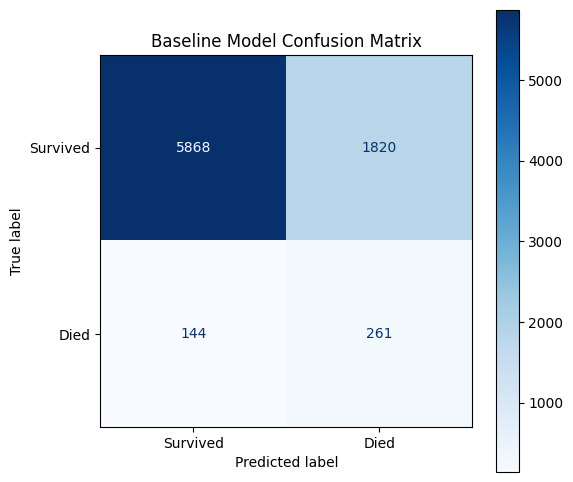

In [100]:
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(model_baseline_logistic, X_test, y_test,
                                      ax=ax, cmap='Blues',
                                      display_labels=['Survived', 'Died'])
plt.title('Baseline Model Confusion Matrix')
plt.show()

## Model - Random Forest

In [101]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score, f1_score
import matplotlib.pyplot as plt

In [102]:
model_baseline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),  
    ('classifier', RandomForestClassifier(
        random_state=42,
        class_weight='balanced',  
        n_jobs=-1 
    ))
])

In [103]:
model_baseline_rf.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [104]:
y_pred_rf = model_baseline_rf.predict(X_test)
y_pred_proba_rf = model_baseline_rf.predict_proba(X_test)[:, 1]

In [105]:
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"  Area Under the Curve (AUC): {auc_rf:.4f}")

f1_rf = f1_score(y_test, y_pred_rf)
print(f"  F1-Score (for Died): {f1_score(y_test, y_pred_rf, pos_label=1):.4f}")

  Area Under the Curve (AUC): 0.7525
  F1-Score (for Died): 0.0239


In [106]:
print(classification_report(y_test, y_pred_rf, target_names=['Survived (0)', 'Died (1)']))

              precision    recall  f1-score   support

Survived (0)       0.95      1.00      0.97      7688
    Died (1)       0.36      0.01      0.02       405

    accuracy                           0.95      8093
   macro avg       0.65      0.51      0.50      8093
weighted avg       0.92      0.95      0.93      8093



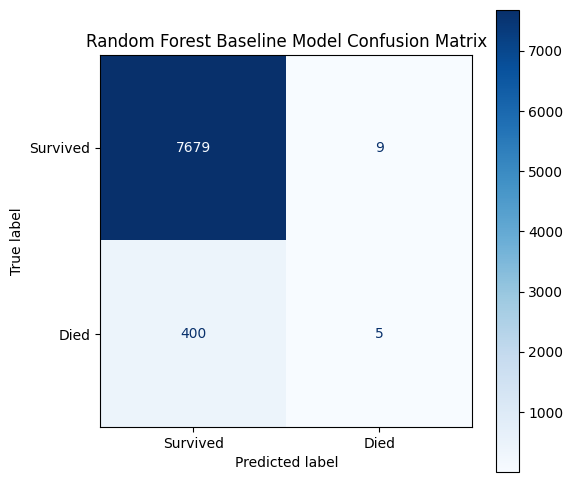

In [107]:
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(model_baseline_rf, X_test, y_test,
                                      ax=ax, cmap='Blues',
                                      display_labels=['Survived', 'Died'])
plt.title('Random Forest Baseline Model Confusion Matrix')
plt.show()